In [1]:
import umap
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
import pandas as pd

/home/rapae/progs/miniconda3x86/envs/titan/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(82, 768)


/home/rapae/progs/miniconda3x86/envs/titan/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


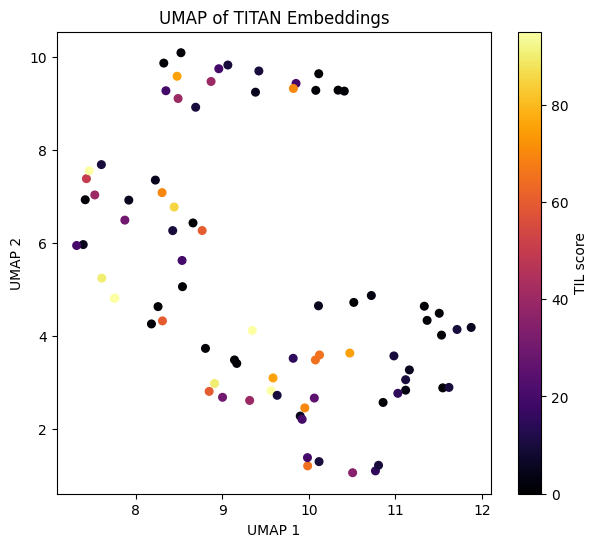

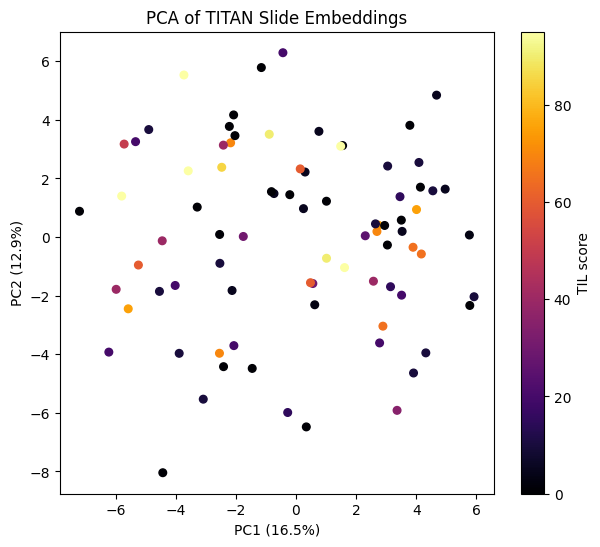

In [2]:
SLIDE_EMBEDDINGS_PATH = "/fast/rapae/BMED6460/group_project/tiger_titan_embeddings_no_pathology_report/X.npy"
METADAT = Path("/fast/rapae/BMED6460/group_project/tiger_titan_embeddings_no_pathology_report/manifest.csv")

WSI_FOLDER_NAME = Path("images")
MASK_FOLDER_NAME = Path("tissue-masks")

CSV_TILS_SCORE = "target"

X = np.load(SLIDE_EMBEDDINGS_PATH)
df = pd.read_csv(METADAT)
labels = df[CSV_TILS_SCORE].astype(float)

print(X.shape)

#UMAP
reducer = umap.UMAP(n_neighbors=4, min_dist=0.1, random_state=42)
emb_2d = reducer.fit_transform(X)

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=labels,
    cmap="inferno",
    s=30
)
plt.colorbar(sc, label="TIL score")
plt.title("UMAP of TITAN Embeddings")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap="inferno",
    s=30
)
plt.colorbar(sc, label="TIL score")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of TITAN Slide Embeddings")
plt.show()


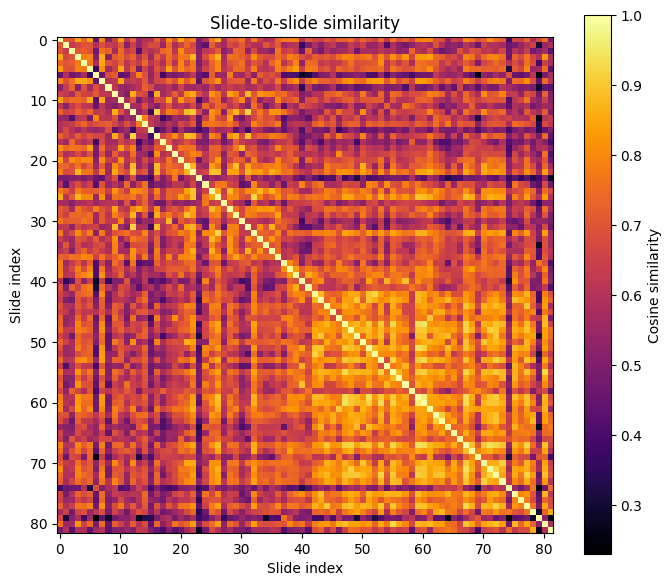

In [3]:
# Cosine similarity heatmap

S = cosine_similarity(X)

plt.figure(figsize=(8, 7))
plt.imshow(S,cmap="inferno")
plt.colorbar(label="Cosine similarity")
plt.title("Slide-to-slide similarity")
plt.xlabel("Slide index")
plt.ylabel("Slide index")
plt.show()

/home/rapae/progs/miniconda3x86/envs/titan/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


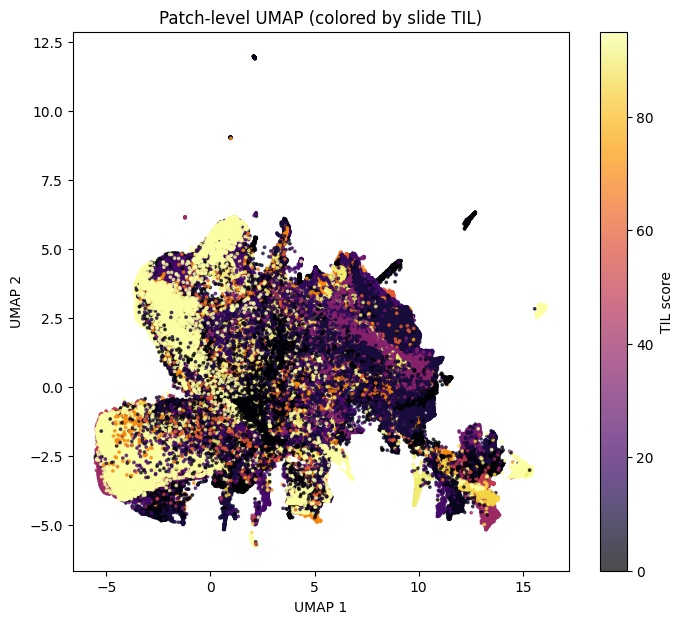

In [6]:
# Patch-level UMAP

slide_ids_patch = np.load("/fast/rapae/BMED6460/group_project/tiger_titan_embeddings_no_pathology_report/slide_ids_patch.npy", allow_pickle=True)
manifest = pd.read_csv(METADAT)

# Create mapping: slide_id → target
slide_to_target = dict(zip(manifest["slide_id"], manifest["target"]))

# Build y_patch
y_patch = np.array([slide_to_target[sid] for sid in slide_ids_patch], dtype=np.float32)

X_patch = np.load("/fast/rapae/BMED6460/group_project/tiger_titan_embeddings_no_pathology_report/X_patch.npy")

max_points = 20000
rng = np.random.default_rng(42)

# if len(X_patch) > max_points:
#     idx = rng.choice(len(X_patch), size=max_points, replace=False)
#     X_plot = X_patch[idx]
#     y_plot = y_patch[idx]
# else:

X_plot = X_patch
y_plot = y_patch

# normalize (recommended)
norms = np.linalg.norm(X_plot, axis=1, keepdims=True)
norms[norms == 0] = 1
X_plot = X_plot / norms

reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

emb_2d = reducer.fit_transform(X_plot)

plt.figure(figsize=(8, 7))
sc = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=y_plot,
    cmap="inferno",
    s=3,
    alpha=0.7
)
plt.colorbar(sc, label="TIL score")
plt.title("Patch-level UMAP (colored by slide TIL)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()